In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.sans-serif'] = ['SimHei']  # 让中文正常显示
plt.rcParams['axes.unicode_minus'] = False    # 让负号正常显示

df = pd.read_csv(r'D:\data_original\clean\user_clean.csv')
df

,user_id,item_id,category_id,behavior_type,timestamp,date,hour
0,1,230380,411153,pv,1511644942,2017-11-26,5
1,1,3745169,2891509,pv,1511725471,2017-11-27,3
2,1,5002615,2520377,pv,1511839385,2017-11-28,11
3,1,4170517,149192,pv,1512011019,2017-11-30,11
4,1,79715,2355072,pv,1512064350,2017-12-01,1
...,...,...,...,...,...,...,...
4995572,540244,4835633,982926,pv,1512020394,2017-11-30,13
4995573,540244,3503021,982926,pv,1512020530,2017-11-30,13
4995574,540244,1951748,1320293,pv,1512022312,2017-11-30,14
4995575,540244,4617991,982926,pv,1512022419,2017-11-30,14


In [2]:
df

,user_id,item_id,category_id,behavior_type,timestamp,date,hour
0,1,230380,411153,pv,1511644942,2017-11-26,5
1,1,3745169,2891509,pv,1511725471,2017-11-27,3
2,1,5002615,2520377,pv,1511839385,2017-11-28,11
3,1,4170517,149192,pv,1512011019,2017-11-30,11
4,1,79715,2355072,pv,1512064350,2017-12-01,1
...,...,...,...,...,...,...,...
4995572,540244,4835633,982926,pv,1512020394,2017-11-30,13
4995573,540244,3503021,982926,pv,1512020530,2017-11-30,13
4995574,540244,1951748,1320293,pv,1512022312,2017-11-30,14
4995575,540244,4617991,982926,pv,1512022419,2017-11-30,14


In [3]:
df_originaldata=df.copy()

In [4]:
print('缺失值统计')
print(df.isnull().sum())

缺失值统计
user_id          0
item_id          0
category_id      0
behavior_type    0
timestamp        0
date             0
hour             0
dtype: int64


In [5]:
df.dtypes

user_id          int64
item_id          int64
category_id      int64
behavior_type      str
timestamp        int64
date               str
hour             int64
dtype: object

In [6]:
df['user_id']=df['user_id'].astype('int32')
df['item_id']=df['item_id'].astype('int32')
df['category_id'] = df['category_id'].astype('int32')
df['hour'] = df['hour'].astype('int8')


In [7]:
#寻找高频异常用户
from scipy import stats
user_pv_count=df[df['behavior_type']=='pv']['user_id'].value_counts()
z_score=stats.zscore(user_pv_count)
super_erroruser=user_pv_count[z_score>3].index
super_erroruser

Index([393983,  54206, 747236, 208813, 299941, 298247, 564280, 277720, 558130,
       343996,
       ...
        51910, 519441, 520226, 521340, 529899, 529939, 530245,  53218, 535065,
       539369],
      dtype='int32', name='user_id', length=9083)

In [8]:
df_user_sorted=df.sort_values(['user_id','timestamp'])
df_user_sorted['timediff']=df_user_sorted.groupby('user_id',as_index=False)['timestamp'].diff()
df_user_sorted
user_average_timediff=df_user_sorted.groupby('user_id')['timediff'].mean()
df_user_sorted['is_abnormal']=df_user_sorted['timediff']<df_user_sorted['user_id'].map(user_average_timediff)*0.5
df_user_sorted['abnormal_level']=0
df_user_sorted.loc[df_user_sorted['timediff']<=0.1,'abnormal_level']=2#严重异常就是2，一般清除
df_user_sorted.loc[(df_user_sorted['timediff']>0.1)&(df_user_sorted['timediff']<1),'abnormal_level']=1#定义轻微异常是1

#df_clean=df_user_sorted[~erroytime].copy()
#df=df_clean.copy()

In [9]:
df_clean=df_user_sorted.copy()

In [10]:
df_clean['is_clean']=~((df_clean['abnormal_level']!=0)|(df_clean['user_id'].isin(super_erroruser)))

In [11]:
df_clean[~df_clean['is_clean']]

,user_id,item_id,category_id,behavior_type,timestamp,date,hour,timediff,is_abnormal,abnormal_level,is_clean
2909246,50,5045605,820727,buy,1512182155,2017-12-02,10,0.0,True,2,False
4118434,143,2904350,4357323,pv,1511589593,2017-11-25,13,NaN,False,0,False
4118435,143,1602868,2640118,fav,1511598119,2017-11-25,16,8526.0,True,0,False
4118436,143,2277923,4606718,pv,1511602678,2017-11-25,17,4559.0,True,0,False
4118437,143,2387779,285583,pv,1511603812,2017-11-25,17,1134.0,True,0,False
...,...,...,...,...,...,...,...,...,...,...,...
4028917,1017717,4794984,4145813,pv,1512226459,2017-12-02,22,35381.0,True,0,False
4028918,1017717,1179874,4756105,pv,1512290485,2017-12-03,16,64026.0,True,0,False
4028919,1017717,2588999,4756105,pv,1512290662,2017-12-03,16,177.0,True,0,False
4028920,1017717,873547,4756105,pv,1512290965,2017-12-03,16,303.0,True,0,False


In [12]:
df=df_clean.copy()

In [13]:
behavior_count=df['behavior_type'].value_counts()
behavior_count

behavior_type
pv      4473617
cart     277130
fav      144821
buy      100009
Name: count, dtype: int64

In [47]:
# 计算各行为类型的总次数（PV 口径）
behavior_count = df['behavior_type'].value_counts()

# 提取各环节行为次数
pv_total = behavior_count.get('pv', 0)
cart_total = behavior_count.get('cart', 0)
fav_total = behavior_count.get('fav', 0)
buy_total = behavior_count.get('buy', 0)

# 计算相对点击转化率
cart_rate = cart_total / pv_total * 100 if pv_total > 0 else 0
fav_rate = fav_total / pv_total * 100 if pv_total > 0 else 0
buy_rate = buy_total / pv_total * 100 if pv_total > 0 else 0

# 输出表格
print("| 环节 | 行为次数 | 相对点击转化率 |")
print(f"| 点击 | {pv_total:,} | 100% |")
print(f"| 加购 | {cart_total:,} | {cart_rate:.2f}% |")
print(f"| 收藏 | {fav_total:,} | {fav_rate:.2f}% |")
print(f"| 购买 | {buy_total:,} | {buy_rate:.2f}% |")

| 环节 | 行为次数 | 相对点击转化率 |
| 点击 | 4,473,617 | 100% |
| 加购 | 277,130 | 6.19% |
| 收藏 | 144,821 | 3.24% |
| 购买 | 100,009 | 2.24% |


In [14]:
print("\n=== 新增：独立用户维度转化漏斗与加购放弃分析===")



=== 新增：独立用户维度转化漏斗与加购放弃分析===


In [15]:
df[df['behavior_type']=='buy']

,user_id,item_id,category_id,behavior_type,timestamp,date,hour,timediff,is_abnormal,abnormal_level,is_clean
2687548,4,572096,2465336,buy,1511870822,2017-11-28,20,3577.0,True,0,True
4155650,16,2435275,3898483,buy,1512143781,2017-12-01,23,99927.0,True,0,True
2248309,20,857379,801221,buy,1512119466,2017-12-01,17,70213.0,True,0,True
413878,27,3424057,128357,buy,1512118560,2017-12-01,16,501.0,True,0,True
2909238,50,2665730,4756105,buy,1512109185,2017-12-01,14,253833.0,True,0,True
...,...,...,...,...,...,...,...,...,...,...,...
4029606,1017987,114448,1464116,buy,1512128744,2017-12-01,19,82014.0,True,0,True
2031528,1017992,4880310,982926,buy,1512111289,2017-12-01,14,132923.0,True,0,True
2031556,1017999,1050602,2089582,buy,1512123009,2017-12-01,18,243506.0,True,0,True
2031559,1017999,1904051,3231625,buy,1512178347,2017-12-02,9,55191.0,True,0,True


In [16]:
user_funnel = df.groupby('user_id')['behavior_type'].apply(set).reset_index()
user_funnel['has_pv']=user_funnel['behavior_type'].apply(lambda x:'pv' in x)
user_funnel['has_cart']=user_funnel['behavior_type'].apply(lambda x:'cart' in x)
user_funnel['has_fav']=user_funnel['behavior_type'].apply(lambda x:'fav' in x)
user_funnel['has_buy']=user_funnel['behavior_type'].apply(lambda x:'buy' in x)

In [17]:
uv_total=len(user_funnel)
uv_pv=user_funnel['has_pv'].sum()
uv_cart=user_funnel['has_cart'].sum()
uv_fav=user_funnel['has_fav'].sum()
uv_buy=user_funnel['has_buy'].sum()

In [18]:
print(f"访问用户数: {uv_pv}")
print(f"加购用户数: {uv_cart} | 访问-加购转化率: {uv_cart/uv_pv:.2%}")
print(f"收藏用户数: {uv_fav} | 访问-收藏转化率: {uv_fav/uv_pv:.2%}")
print(f"成交用户数: {uv_buy} | 访问-支付转化率: {uv_buy/uv_pv:.2%}")


访问用户数: 469197
加购用户数: 162255 | 访问-加购转化率: 34.58%
收藏用户数: 77283 | 访问-收藏转化率: 16.47%
成交用户数: 82067 | 访问-支付转化率: 17.49%


In [19]:
cart_users = df[df['behavior_type'] == 'cart']['user_id'].unique()
buy_users = df[df['behavior_type'] == 'buy']['user_id'].unique()
cart_buy_users = set(cart_users) & set(buy_users)
abandon_rate = 1 - (len(cart_buy_users) / len(cart_users))
print(f"加购用户数: {len(cart_users)}")
print(f"加购用户最终购买比例: {len(cart_buy_users)/len(cart_users):.2%}")
print(f"加购后放弃率: {abandon_rate:.2%}  -> 【核心优化点】")

加购用户数: 162255
加购用户最终购买比例: 20.73%
加购后放弃率: 79.27%  -> 【核心优化点】


In [20]:
#关于用户加购总次数对其总购物是否有关联性，并非对其进行已加购进一步购买的分析
cart_behavior=df[df['behavior_type']=='cart']
cart_by_user=cart_behavior.groupby('user_id').size().reset_index(name='cart_times')
#进一步研究买
user_has_buy=user_funnel[['user_id','has_buy']]
cart_with_buy=cart_by_user.merge(user_has_buy,on='user_id')
cart_with_buy.groupby(pd.cut(cart_with_buy['cart_times'],bins=[0,1,2,3,5,100])).agg(
    人数=('user_id','count'),
    购买比例=('has_buy','mean')
)

,人数,购买比例
cart_times,,
"(0, 1]",96978,0.189950
"(1, 2]",37834,0.217529
"(2, 3]",15586,0.235275
"(3, 5]",9402,0.272921
"(5, 100]",2455,0.303462


In [21]:
# 在 user_funnel 表上直接算
fav_users = user_funnel[user_funnel['has_fav']]               # 有过收藏行为的用户
fav_buy_users = user_funnel[user_funnel['has_fav'] & user_funnel['has_buy']]  # 收藏过且购买了

num_fav = len(fav_users)
num_fav_buy = len(fav_buy_users)

print(f"收藏用户数: {num_fav}")
print(f"收藏且购买用户数: {num_fav_buy}")
print(f"收藏→购买转化率: {num_fav_buy / num_fav:.2%}")
print(f"收藏后流失率: {1 - num_fav_buy / num_fav:.2%}")

收藏用户数: 77283
收藏且购买用户数: 14990
收藏→购买转化率: 19.40%
收藏后流失率: 80.60%


In [22]:
behavior_count = df['behavior_type'].value_counts()
pv_total = behavior_count.get('pv', 0)
cart_total = behavior_count.get('cart', 0)
fav_total = behavior_count.get('fav', 0)
buy_total = behavior_count.get('buy', 0)

print(f"点击次数: {pv_total}")
print(f"加购次数: {cart_total} | 点击→加购: {cart_total/pv_total:.2%}")
print(f"收藏次数: {fav_total} | 点击→收藏: {fav_total/pv_total:.2%}")
print(f"购买次数: {buy_total} | 点击→购买: {buy_total/pv_total:.2%}")

点击次数: 4473617
加购次数: 277130 | 点击→加购: 6.19%
收藏次数: 144821 | 点击→收藏: 3.24%
购买次数: 100009 | 点击→购买: 2.24%


In [23]:
# 每个用户的行为次数
user_behavior_depth = df.groupby('user_id').size().reset_index(name='total_actions')

# 按深度分箱
depth_bins = [0, 1, 5, 10, 20, 50, 100, 500]
print(user_behavior_depth.groupby(pd.cut(user_behavior_depth['total_actions'], bins=depth_bins)).size())

total_actions
(0, 1]        30462
(1, 5]       142822
(5, 10]      125807
(10, 20]     116844
(20, 50]      58738
(50, 100]      1834
dtype: int64


In [24]:
# 计算全平台各行为的 PV（总次数）、UV（独立用户数）、人均次数
behavior_stats = df.groupby('behavior_type').agg(
    总次数=('user_id', 'count'),      # PV
    用户数=('user_id', 'nunique')     # UV
).reset_index()

behavior_stats['人均次数'] = behavior_stats['总次数'] / behavior_stats['用户数']

# 按业务习惯排序：pv → cart → fav → buy
order = ['pv', 'cart', 'fav', 'buy']
behavior_stats['sort'] = behavior_stats['behavior_type'].apply(lambda x: order.index(x) if x in order else 99)
behavior_stats = behavior_stats.sort_values('sort').drop(columns='sort')

print(behavior_stats)

  behavior_type      总次数     用户数      人均次数
3            pv  4473617  469197  9.534624
1          cart   277130  162255  1.707991
2           fav   144821   77283  1.873905
0           buy   100009   82067  1.218626


In [25]:
#计算一下转化率，我需要知道用户点击与收藏购买加购的关系
'''funnel=pd.DataFrame(
    {
     '用户操作':['点击','加购','收藏','购买'],
     '人数':[pv,cart,fav,buy],
     '转化率(相对于pv)':[1.0,cart/pv,fav/pv,buy/pv],
     '转化率(相对于购买)':[buy/pv,buy/cart,buy/fav,buy/buy]
    }
)
print(funnel)'''

"funnel=pd.DataFrame(\n    {\n     '用户操作':['点击','加购','收藏','购买'],\n     '人数':[pv,cart,fav,buy],\n     '转化率(相对于pv)':[1.0,cart/pv,fav/pv,buy/pv],\n     '转化率(相对于购买)':[buy/pv,buy/cart,buy/fav,buy/buy]\n    }\n)\nprint(funnel)"

In [26]:
'''plt.figure(figsize=(10, 6))
sns.barplot(x='用户操作', y='人数', data=funnel, palette='Blues_d')
plt.title('淘宝用户行为转化漏斗')
plt.ylabel('用户行为次数')
plt.savefig('funnel.png', dpi=300)
plt.show()'''


"plt.figure(figsize=(10, 6))\nsns.barplot(x='用户操作', y='人数', data=funnel, palette='Blues_d')\nplt.title('淘宝用户行为转化漏斗')\nplt.ylabel('用户行为次数')\nplt.savefig('funnel.png', dpi=300)\nplt.show()"

In [27]:
df

,user_id,item_id,category_id,behavior_type,timestamp,date,hour,timediff,is_abnormal,abnormal_level,is_clean
0,1,230380,411153,pv,1511644942,2017-11-26,5,NaN,False,0,True
1,1,3745169,2891509,pv,1511725471,2017-11-27,3,80529.0,True,0,True
2,1,5002615,2520377,pv,1511839385,2017-11-28,11,113914.0,True,0,True
3,1,4170517,149192,pv,1512011019,2017-11-30,11,171634.0,True,0,True
4,1,79715,2355072,pv,1512064350,2017-12-01,1,53331.0,True,0,True
...,...,...,...,...,...,...,...,...,...,...,...
39790,1018000,1781906,4801426,pv,1512175643,2017-12-02,8,395388.0,True,0,True
39791,1018000,585262,1029459,pv,1512299996,2017-12-03,19,124353.0,True,0,True
39792,1018000,2201514,2558244,pv,1512300087,2017-12-03,19,91.0,True,0,True
39793,1018000,1745865,3738615,pv,1512307549,2017-12-03,21,7462.0,True,0,True


In [28]:
hour_active=df.groupby('hour')['user_id'].nunique()
hour_active

hour
0      78537
1      38420
2      21798
3      15224
4      13485
5      17664
6      37223
7      68467
8      93617
9     112696
10    129175
11    128318
12    129385
13    136497
14    135577
15    139323
16    135257
17    127293
18    128692
19    149120
20    168945
21    183266
22    177160
23    136187
Name: user_id, dtype: int64

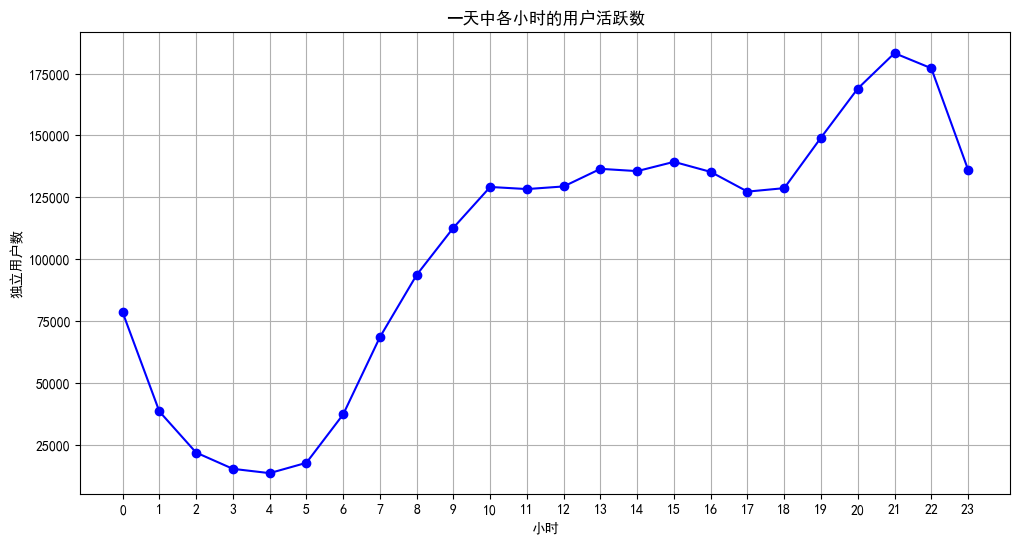

In [29]:
plt.figure(figsize=(12, 6))
hour_active.plot(kind='line', marker='o', color='blue')
plt.title('一天中各小时的用户活跃数')
plt.xlabel('小时')
plt.ylabel('独立用户数')
plt.xticks(range(0, 24))
plt.grid(True)
plt.savefig('hourly_active.png', dpi=300)
plt.show()


In [30]:
df

,user_id,item_id,category_id,behavior_type,timestamp,date,hour,timediff,is_abnormal,abnormal_level,is_clean
0,1,230380,411153,pv,1511644942,2017-11-26,5,NaN,False,0,True
1,1,3745169,2891509,pv,1511725471,2017-11-27,3,80529.0,True,0,True
2,1,5002615,2520377,pv,1511839385,2017-11-28,11,113914.0,True,0,True
3,1,4170517,149192,pv,1512011019,2017-11-30,11,171634.0,True,0,True
4,1,79715,2355072,pv,1512064350,2017-12-01,1,53331.0,True,0,True
...,...,...,...,...,...,...,...,...,...,...,...
39790,1018000,1781906,4801426,pv,1512175643,2017-12-02,8,395388.0,True,0,True
39791,1018000,585262,1029459,pv,1512299996,2017-12-03,19,124353.0,True,0,True
39792,1018000,2201514,2558244,pv,1512300087,2017-12-03,19,91.0,True,0,True
39793,1018000,1745865,3738615,pv,1512307549,2017-12-03,21,7462.0,True,0,True


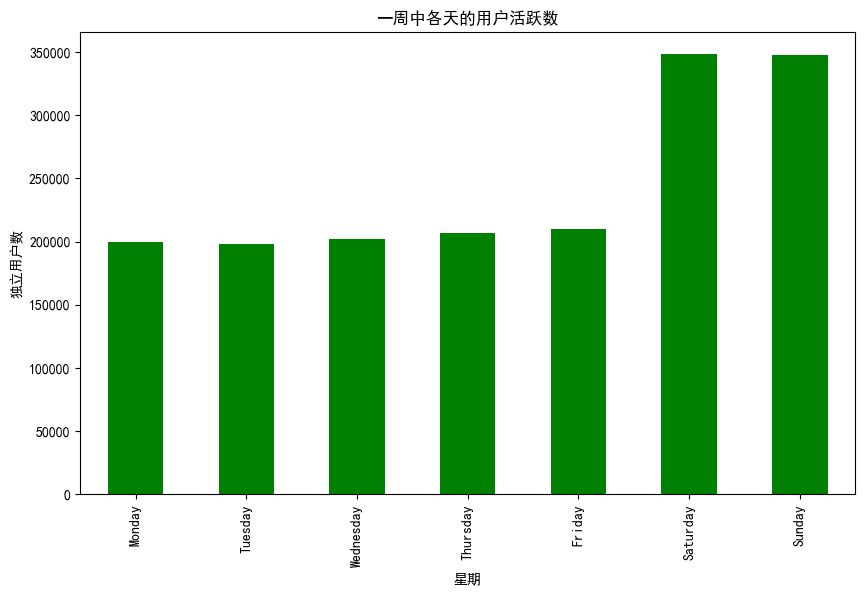

In [31]:
df['weekday']=pd.to_datetime(df['date']).dt.day_name()
df
weekday_order= ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_active=df.groupby('weekday')['user_id'].nunique().reindex(weekday_order)
plt.figure(figsize=(10, 6))
weekday_active.plot(kind='bar', color='green')
plt.title('一周中各天的用户活跃数')
plt.xlabel('星期')
plt.ylabel('独立用户数')
plt.savefig('weekday_active.png', dpi=300)
plt.show()


In [32]:
#RFM分层模型
buy_on=df[df['behavior_type']=='buy']
rfm = buy_on.groupby('user_id').agg({
    'date':lambda x: (pd.to_datetime('2017-12-03')-pd.to_datetime(x.max())).days,
    'item_id':'count'}
).rename(columns={'date':'R','item_id':'F'})
rfm['R_score']=pd.cut(rfm['R'],bins=[-1,1,3,5,7,9],labels=[5,4,3,2,1])
rfm['F_score']=pd.cut(rfm['F'],bins=[0,1,2,3,4,100],labels=[1,2,3,4,5])
rfm['R_score']=rfm['R_score'].astype(int)
rfm['F_score']=rfm['F_score'].astype(int)


In [33]:
rfm

,R,F,R_score,F_score
user_id,,,,
4,5,1,3,1
16,2,1,4,1
20,2,1,4,1
27,2,1,4,1
50,1,4,5,4
...,...,...,...,...
1017968,2,1,4,1
1017983,2,1,4,1
1017987,2,1,4,1


In [34]:
import numpy as np

rfm['segment']=np.select(
    [(rfm['R_score']>=4)&(rfm['F_score']>=4),
     (rfm['R_score']>=4)&(rfm['F_score']<4),
     (rfm['R_score']<4)&(rfm['F_score']>=4),
    ],
    ['重要价值用户','重要发展用户','重要保持用户'],
    default='一般价值用户'
)


In [35]:
# ==================== 新增统计学检验 ====================
from scipy import stats

# 对比重要价值用户与一般价值用户的平均购买次数差异
high_value = rfm[rfm['segment'] == '重要价值用户']['F']
low_value = rfm[rfm['segment'] == '一般价值用户']['F']
t_stat, p_value = stats.ttest_ind(high_value, low_value)
print(f"t值为{t_stat}")
print(f"独立样本T检验 P值: {p_value:.2e}")
if p_value < 0.05:
    print("结论: 两类用户的购买频率存在显著统计差异，分层策略有效。")

t值为206.9985273994516
独立样本T检验 P值: 0.00e+00
结论: 两类用户的购买频率存在显著统计差异，分层策略有效。


In [36]:
rfm

,R,F,R_score,F_score,segment
user_id,,,,,
4,5,1,3,1,一般价值用户
16,2,1,4,1,重要发展用户
20,2,1,4,1,重要发展用户
27,2,1,4,1,重要发展用户
50,1,4,5,4,重要价值用户
...,...,...,...,...,...
1017968,2,1,4,1,重要发展用户
1017983,2,1,4,1,重要发展用户
1017987,2,1,4,1,重要发展用户


In [37]:
segment_counts=rfm['segment'].value_counts()
segment_percent=segment_counts/len(rfm)*100
print('用户分层结果')
print(pd.concat([segment_counts,segment_percent],axis=1,keys=['人数','占比(%)']))

用户分层结果
            人数      占比(%)
segment                  
重要发展用户   41429  50.481923
一般价值用户   39916  48.638308
重要价值用户     571   0.695773
重要保持用户     151   0.183996


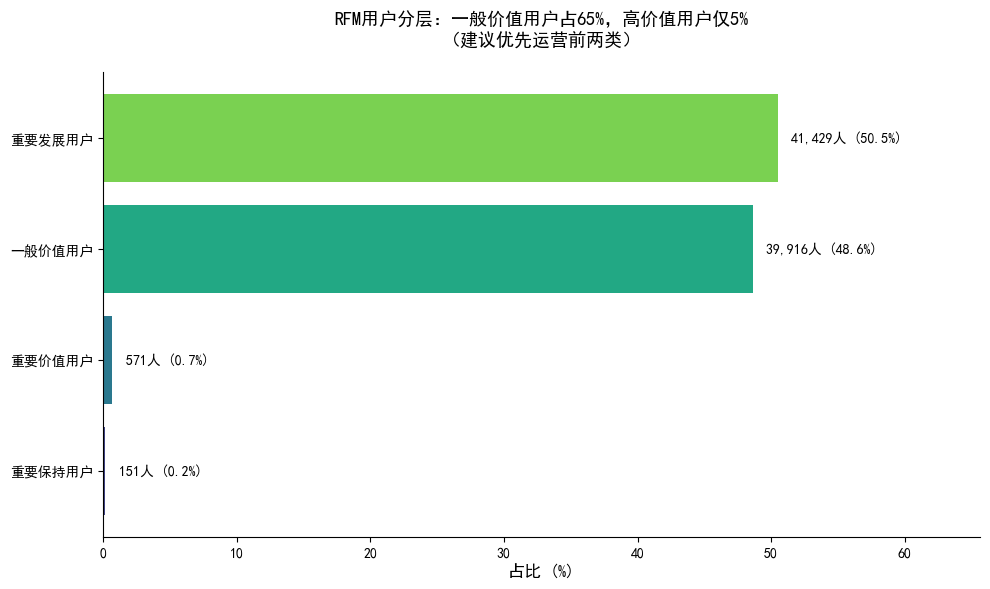

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# 准备数据：按占比降序
segment_data = rfm['segment'].value_counts().reset_index()
segment_data.columns = ['用户类型', '人数']
segment_data['占比'] = segment_data['人数'] / segment_data['人数'].sum() * 100
segment_data = segment_data.sort_values('占比', ascending=True)  # 条形图升序好看

# 创建条形图
fig, ax = plt.subplots(figsize=(10, 6))

# 水平条形图（类别名长时更易读）
bars = ax.barh(segment_data['用户类型'], segment_data['占比'], 
               color=sns.color_palette('viridis', len(segment_data)))

# 添加数值标签
for i, (idx, row) in enumerate(segment_data.iterrows()):
    ax.text(row['占比'] + 1, i, 
            f"{row['人数']:,}人 ({row['占比']:.1f}%)", 
            va='center', fontsize=10)

# 标题和标签
ax.set_xlabel('占比 (%)', fontsize=12)
ax.set_title('RFM用户分层：一般价值用户占65%，高价值用户仅5%\n（建议优先运营前两类）', 
             fontsize=13, pad=20)

# 美化
ax.set_xlim(0, max(segment_data['占比']) * 1.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('rfm_segment_v2.png', dpi=300, bbox_inches='tight')
plt.show()


In [39]:
top_pv_items=df[df['behavior_type']=='pv']['item_id'].value_counts().head()
top_pv_items

item_id
812879     1538
3845720    1307
138964     1038
2331370     957
2032668     953
Name: count, dtype: int64

In [40]:
top_buy_items=df[df['behavior_type']=='buy']['item_id'].value_counts().head()
top_buy_items

item_id
3122135    70
3031354    47
1910706    38
2560262    34
1116492    32
Name: count, dtype: int64

In [41]:

item_stats = df.groupby('item_id').agg(
    pv_count=('behavior_type', lambda x: (x == 'pv').sum()),
    buy_count=('behavior_type', lambda x: (x == 'buy').sum()),
    category=('category_id','first')
).fillna(0)

item_stats['conversion_rate']=np.where(
    item_stats['pv_count']>0,
    item_stats['buy_count'] / item_stats['pv_count'],
    0
)
high_conversion_items=(item_stats[item_stats['pv_count']>100].sort_values('conversion_rate',ascending=False).head(10))

print("购买转化率最高的前10个商品：")
print(high_conversion_items)


购买转化率最高的前10个商品：
         pv_count  buy_count  category  conversion_rate
item_id                                                
4265551       107         21   4138583         0.196262
1074025       124         23   1464116         0.185484
1344014       106         18    970709         0.169811
257772        131         21   3848953         0.160305
3637124       101         16    970709         0.158416
1861309       120         19   1573465         0.158333
5051027       170         26   3354186         0.152941
3189426       179         27    800581         0.150838
3503155       126         19   4138583         0.150794
267531        154         23   1813610         0.149351


In [42]:
top100=item_stats[item_stats['pv_count']>100].sort_values('conversion_rate',ascending=False).head(100)
item_category = df[['item_id', 'category_id']].drop_duplicates()
top100_cat=top100.merge(item_category,how='left',on='item_id')
cat_stats=top100_cat.groupby('category_id').agg(
    item_count=('item_id','count'),
    aver_stats=('conversion_rate','mean'),
    buy_total=('buy_count','sum')
).sort_values('item_count',ascending=False)
print(cat_stats.head(5))

             item_count  aver_stats  buy_total
category_id                                   
2735466               9    0.083649        100
1464116               7    0.113100        102
903809                5    0.088358         81
1265358               3    0.073989         43
2774299               3    0.111050         60


In [46]:
# ==================== 新增：商品波士顿矩阵（流量-转化矩阵） ====================
# 计算每个商品的总PV和转化率
item_matrix = df.groupby('item_id').agg(
    total_pv=('behavior_type', lambda x: (x == 'pv').sum()),
    total_buy=('behavior_type', lambda x: (x == 'buy').sum())
)
item_matrix['cvr'] = item_matrix['total_buy'] / item_matrix['total_pv']
item_matrix=item_matrix[item_matrix['total_pv']>0].copy()
min_pv=5
item_matrix=item_matrix[item_matrix['total_pv']>min_pv].copy()
pv_medain=item_matrix['total_pv'].median()
cvr_m=item_matrix['cvr']>0
def classify_item(row):
    high_pv=row['total_pv']>=pv_medain
    high_cvr=row['cvr']>0
    if high_cvr and high_pv:
        return '明星商品'
    elif high_pv and not high_cvr:
        return '金牛商品'
    elif not high_pv and high_cvr:
        return '潜力商品'
    else:
        return '瘦狗商品'
item_matrix['category']=item_matrix.apply(classify_item,axis=1)
category_counts = item_matrix['category'].value_counts().reindex(['明星商品', '金牛商品', '潜力商品', '瘦狗商品'])
print(category_counts)


category
明星商品    23584
金牛商品    62542
潜力商品     8853
瘦狗商品    65276
Name: count, dtype: int64


In [ ]:
# 绘制散点图
plt.figure(figsize=(10, 6))
plt.scatter(item_matrix['total_pv'], item_matrix['cvr'], alpha=0.5)
plt.xscale('log') # 流量通常符合长尾分布
plt.axhline(y=item_matrix['cvr'].median(), color='r', linestyle='--', label='转化率中位数')
plt.axvline(x=item_matrix['total_pv'].median(), color='g', linestyle='--', label='流量中位数')
plt.xlabel('点击量 (PV) - 对数刻度')
plt.ylabel('购买转化率 (CVR)')
plt.title('商品流量效率波士顿矩阵')
plt.legend()
plt.show()

# 识别象限
# 右上：明星商品 (高流量高转化) -> 加大采买
# 右下：金牛商品 (高流量低转化) -> 优化详情页或降价清仓
# 左上：潜力商品 (低流量高转化) -> 增加曝光资源位
# 左下：瘦狗商品 (低流量低转化) -> 考虑下架